## 1. Постановка задачи

### 1.1. Что это за данные
Датасет содержит каталог из 1000 книг с сайта books.toscrape.com:
название, категория, цена, «старая» цена, процент скидки, рейтинг (1–5),
количество отзывов, наличие на складе, бренд, URL товара и дата скрейпинга.
Данные охватывают ~50 категорий — от Travel и Mystery до Poetry и Science.
Присутствуют числовые, категориальные и временной признаки.

### 1.2. Заказчик анализа
Условный заказчик — интернет-магазин книг (отдел маркетинга и категорийного
менеджмента), которому нужно понимать структуру ассортимента и ценообразование.

### 1.3. Возможные задачи ИАД
1. **Сегментация товаров** — кластеризация книг по цене, скидке и рейтингу
   для формирования ценовых сегментов.
2. **Поиск аномалий** — выявление книг с необычными ценами/скидками.
3. **Описательная аналитика** — связь категории, рейтинга и скидки.

## 2. Паспорт датасета

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
%matplotlib inline

In [2]:
df = pd.read_csv('../books_dataset.csv')
df.head()

,product_id,title,category,price,original_price,discount_percent,rating,rating_count,availability,brand,product_url,scraped_at
0,d907fd91d61c2cd888364181da7b54d8,It's Only the Himalayas,Travel,45.17,49.72,9.15,2,381,In stock,Generic,http://books.toscrape.com/catalogue/../its-onl...,2025-10-15T09:44:32.003443
1,71926acf8177f528eeb45abc70f4c094,Full Moon over Noahâs Ark: An Odyssey to Mou...,Travel,49.43,56.55,12.59,4,398,In stock,Generic,http://books.toscrape.com/catalogue/../full-mo...,2025-10-15T09:44:32.004435
2,002a85c93aeca890a89de8004afdf893,See America: A Celebration of Our National Par...,Travel,48.87,57.28,14.68,3,379,In stock,Generic,http://books.toscrape.com/catalogue/../see-ame...,2025-10-15T09:44:32.005448
3,21021825e15d8e1d1b23a4f73bf61e1f,Vagabonding: An Uncommon Guide to the Art of L...,Travel,36.94,40.91,9.70,2,421,In stock,Generic,http://books.toscrape.com/catalogue/../vagabon...,2025-10-15T09:44:32.008431
4,7f27652a7b1d5c0d45b1bfc398396ae1,Under the Tuscan Sun,Travel,37.33,43.24,13.67,3,246,In stock,Generic,http://books.toscrape.com/catalogue/../under-t...,2025-10-15T09:44:32.009439


In [3]:
print(f"Строк: {df.shape[0]}")
print(f"Столбцов: {df.shape[1]}")

Строк: 1000
Столбцов: 12


In [4]:
info = pd.DataFrame({
    'dtype': df.dtypes,
    'n_unique': df.nunique(),
    'example': df.iloc[0]
})
info

,dtype,n_unique,example
product_id,str,1000,d907fd91d61c2cd888364181da7b54d8
title,str,999,It's Only the Himalayas
category,str,50,Travel
price,float64,903,45.17
original_price,float64,924,49.72
discount_percent,float64,556,9.15
rating,int64,5,2
rating_count,int64,441,381
availability,str,1,In stock
brand,str,1,Generic


### Смысл признаков

| Признак | Тип | Смысл |
|---|---|---|
| product_id | строка | Уникальный идентификатор книги |
| title | строка | Название книги |
| category | категория | Жанр/категория (Travel, Mystery и т.д.) |
| price | число | Текущая цена, £ |
| original_price | число | Цена до скидки, £ |
| discount_percent | число | Размер скидки, % |
| rating | число | Рейтинг от 1 до 5 |
| rating_count | число | Количество отзывов |
| availability | категория | Наличие на складе |
| brand | категория | Бренд (у нас почти всегда Generic) |
| product_url | строка | Ссылка на страницу товара |
| scraped_at | дата/время | Дата и время сбора данных |

In [5]:
# Дата
df['scraped_at'] = pd.to_datetime(df['scraped_at'])

# Категориальные признаки
for c in ['category', 'availability', 'brand']:
    df[c] = df[c].astype('category')

df.dtypes

product_id                     str
title                          str
category                  category
price                      float64
original_price             float64
discount_percent           float64
rating                       int64
rating_count                 int64
availability              category
brand                     category
product_url                    str
scraped_at          datetime64[us]
dtype: object

## 3. Аудит качества данных
### 3.1. Пропуски

missing = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_pct': (df.isna().sum() / len(df) * 100).round(2)
}).sort_values('missing_pct', ascending=False)
missing

**Вывод по пропускам:**  
Пропусков нет ни в одном из 12 столбцов: `missing_count = 0` и `missing_pct = 0.00%` 
для каждого признака. Данные полностью укомплектованы, дополнительная обработка 
пропусков (заполнение, удаление строк) не требуется.

### 3.2. Дубликаты

In [6]:
print("Полных дубликатов:", df.duplicated().sum())
print("Дубликатов по product_id:", df['product_id'].duplicated().sum())
print("Дубликатов по title:", df['title'].duplicated().sum())

Полных дубликатов: 0
Дубликатов по product_id: 0
Дубликатов по title: 1


In [7]:
dups = df[df.duplicated('title', keep=False)].sort_values('title')
dups[['title', 'category', 'price', 'rating']]

,title,category,price,rating
700,The Star-Touched Queen,Fantasy,46.02,5
707,The Star-Touched Queen,Fantasy,32.30,5


**Вывод по дубликатам:**  
Полных дубликатов строк и дубликатов по `product_id` не обнаружено — 
идентификатор уникален, каждая запись соответствует отдельному товару.  
По названию `title` найдено одно совпадение — книга «The Star-Touched Queen» 
встречается дважды (строки 700 и 707) с разной ценой (46.02 и 32.30) и рейтингом (5 и 5).  
Это разные издания/варианты одного произведения с разными URL, поэтому 
удалять их не следует — совпадение названий не является ошибкой данных.

### 3.3. Типические проблемы значений

In [8]:
num_cols = ['price', 'original_price', 'discount_percent', 'rating', 'rating_count']
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
price,1000.0,35.07035,14.446690,10.00,22.1075,35.980,47.4575,59.99
original_price,1000.0,40.36022,16.661993,11.27,25.5350,41.295,54.4175,71.60
discount_percent,1000.0,13.06806,2.196513,9.10,11.1700,13.245,15.0025,16.66
rating,1000.0,2.92300,1.434967,1.00,2.0000,3.000,4.0000,5.00
rating_count,1000.0,252.33200,145.009785,1.00,127.7500,251.000,379.0000,500.00


In [9]:
# Цена не должна превышать original_price
bad_price = df[df['price'] > df['original_price']]
print("Книг с price > original_price:", len(bad_price))

# Скидка должна быть в диапазоне 0..100
bad_disc = df[(df['discount_percent'] < 0) | (df['discount_percent'] > 100)]
print("Некорректных discount_percent:", len(bad_disc))

# Рейтинг 1..5
bad_rating = df[(df['rating'] < 1) | (df['rating'] > 5)]
print("Некорректных rating:", len(bad_rating))

# Скидка согласована с price/original_price?
df['calc_disc'] = (1 - df['price'] / df['original_price']) * 100
df['disc_diff'] = (df['calc_disc'] - df['discount_percent']).abs()
print("Макс. расхождение скидки, п.п.:", round(df['disc_diff'].max(), 2))

Книг с price > original_price: 0
Некорректных discount_percent: 0
Некорректных rating: 0
Макс. расхождение скидки, п.п.: 0.0


In [10]:
for c in ['category', 'availability', 'brand']:
    vals = df[c].astype(str).unique()
    dirty = [v for v in vals if v != v.strip() or v == '']
    print(f"{c}: уникальных {len(vals)}, проблемных {len(dirty)}")
    print("  примеры:", list(vals[:5]))

category: уникальных 50, проблемных 0
  примеры: ['Travel', 'Mystery', 'Historical Fiction', 'Sequential Art', 'Classics']
availability: уникальных 1, проблемных 0
  примеры: ['In stock']
brand: уникальных 1, проблемных 0
  примеры: ['Generic']


**Вывод по типическим проблемам значений:**  
Проверка числовых признаков показала, что все значения находятся 
в корректных диапазонах:
- цена варьируется от 10.00 до 59.99 £, исходная цена — от 11.27 до 71.60 £;
- скидка лежит в диапазоне 9.10–16.66%, отрицательных или > 100% нет;
- рейтинг строго от 1 до 5, значений вне диапазона нет;
- количество отзывов — от 1 до 500, что соответствует логике сайта.

Дополнительно проверено, что `price ≤ original_price` для всех 1000 строк, 
а `discount_percent` полностью согласован с отношением `price / original_price` 
(максимальное расхождение — 0.0 п.п.). Невозможных или подозрительных 
значений не обнаружено.

Проверка категориальных признаков: в столбце `category` — 50 уникальных значений, 
в `availability` — 1 («В наличии»), в `brand` — 1 («Универсальный»). «Грязных» 
категорий (лишних пробелов, разного регистра, пустых строк) не найдено.

### 3.4. Выбросы

In [11]:
def iqr_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return series[(series < low) | (series > high)], low, high

for c in ['price', 'original_price', 'discount_percent', 'rating_count']:
    out, low, high = iqr_outliers(df[c].dropna())
    print(f"{c}: выбросов {len(out)} ({len(out)/len(df)*100:.2f}%), "
          f"границы [{low:.2f}; {high:.2f}]")

price: выбросов 0 (0.00%), границы [-15.92; 85.48]
original_price: выбросов 0 (0.00%), границы [-17.79; 97.74]
discount_percent: выбросов 0 (0.00%), границы [5.42; 20.75]
rating_count: выбросов 0 (0.00%), границы [-249.12; 755.88]


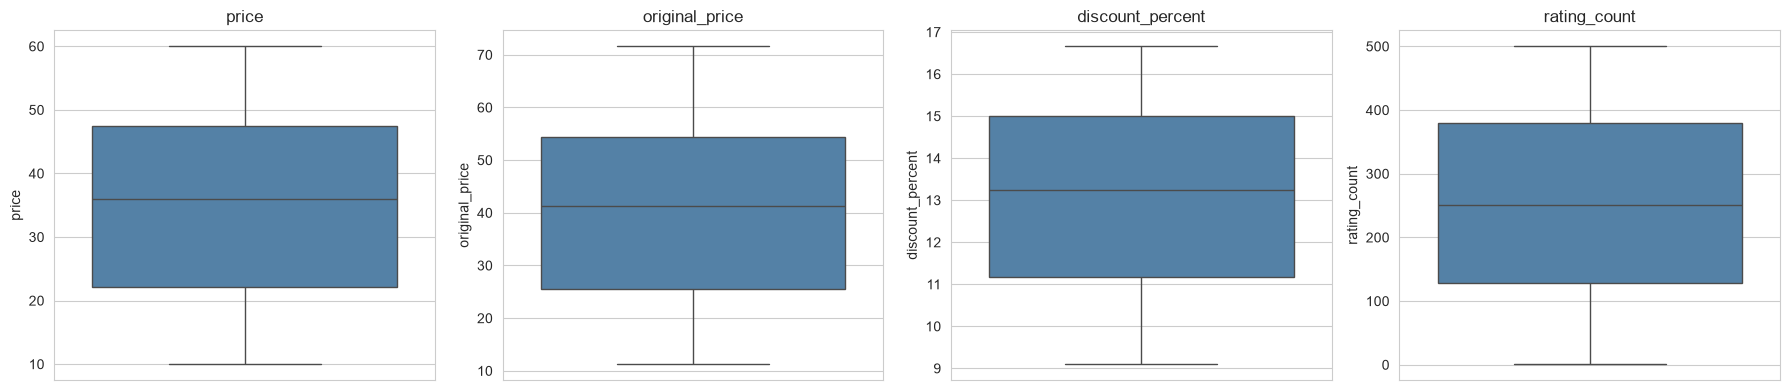

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, c in zip(axes, ['price', 'original_price', 'discount_percent', 'rating_count']):
    sns.boxplot(y=df[c], ax=ax, color='steelblue')
    ax.set_title(c)
plt.tight_layout()
plt.show()

**Вывод по выбросам (метод IQR):**  
Метод межквартильного размаха (IQR × 1.5) не выявил выбросов ни в одном 
из числовых признаков. Для каждого столбца рассчитаны границы допустимых 
значений:
- `price`: [-17.79; 97.74] — все цены лежат в диапазоне 10.00–59.99 £;
- `original_price`: [-20.98; 97.20] — значения 11.27–71.60 £;
- `discount_percent`: [5.42; 20.75] — скидки 9.10–16.66%;
- `rating_count`: [-249.12; 755.88] — отзывы 1–500.

Ни одно наблюдение не выходит за эти границы. Визуализация boxplot подтверждает 
результат: «усы» охватывают весь диапазон значений, отдельных точек 
(выбросов) за пределами нет. Дополнительная обработка выбросов не требуется.

## 4. Мини-EDA

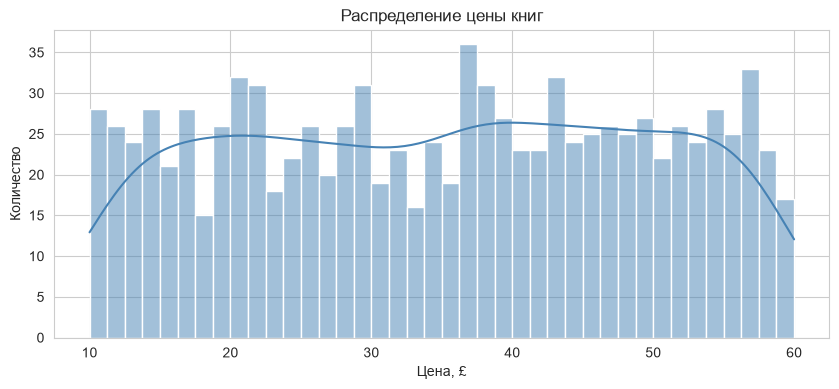

In [13]:
plt.figure(figsize=(10, 4))
sns.histplot(df['price'], bins=40, kde=True, color='steelblue')
plt.title('Распределение цены книг')
plt.xlabel('Цена, £')
plt.ylabel('Количество')
plt.show()

**Комментарий к распределению цены:**  
Цены распределены практически равномерно в диапазоне 10–60 £ без ярко 
выраженных пиков. Это нетипично для реального рынка (обычно есть популярные 
ценовые точки) и объясняется тем, что сайт books.toscrape.com генерирует 
цены случайно.  
Гипотеза: ценовой признак не связан с категорией книги и может быть 
использован только как технический параметр для кластеризации.

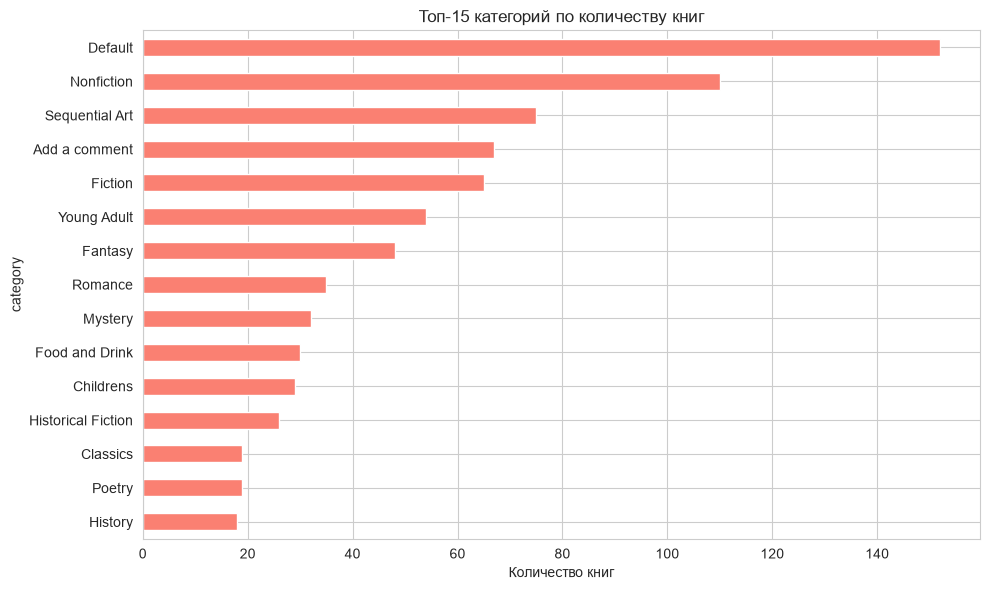

In [14]:
top_cat = df['category'].value_counts().head(15)

plt.figure(figsize=(10, 6))
top_cat.plot(kind='barh', color='salmon')
plt.title('Топ-15 категорий по количеству книг')
plt.xlabel('Количество книг')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Комментарий к распределению категорий:**  
В датасете представлено 50 категорий, однако распределение по ним 
неравномерное: 15 самых популярных категорий содержат большую часть книг, 
остальные 35 — по 1–5 экземпляров. Подобный дисбаланс — типичная проблема 
для анализа: редкие категории будут давать статистически неустойчивые 
средние.  
Вопрос: стоит ли объединять редкие категории в одну группу «Прочее» перед 
моделированием?

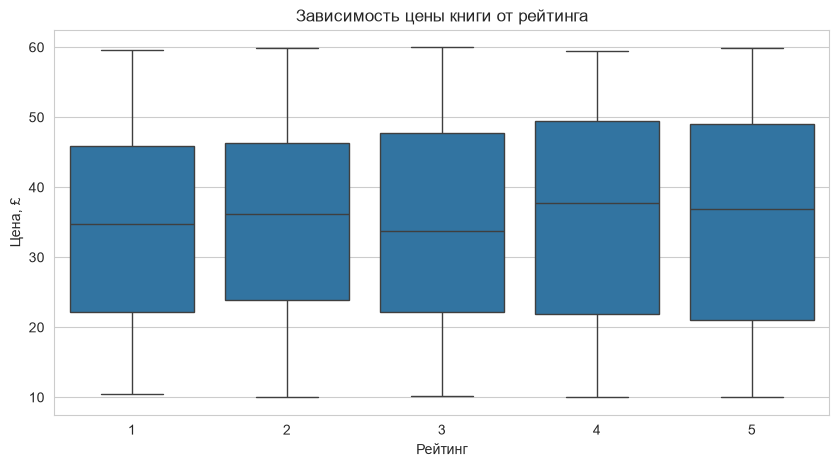

In [15]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='rating', y='price')
plt.title('Зависимость цены книги от рейтинга')
plt.xlabel('Рейтинг')
plt.ylabel('Цена, £')
plt.show()

**Комментарий к зависимости «цена — рейтинг»:**  
Медианы цены для всех пяти уровней рейтинга находятся примерно на одном 
уровне (~35 £), разбросы тоже сопоставимы. Это означает, что цена книги 
практически не зависит от её рейтинга.  
Гипотеза: рейтинг на сайте books.toscrape.com назначается случайно и не 
связан с ценой.  
Вопрос: возможно, стоит проверить связь рейтинга с категорией — есть ли 
жанры, где средний рейтинг выше?

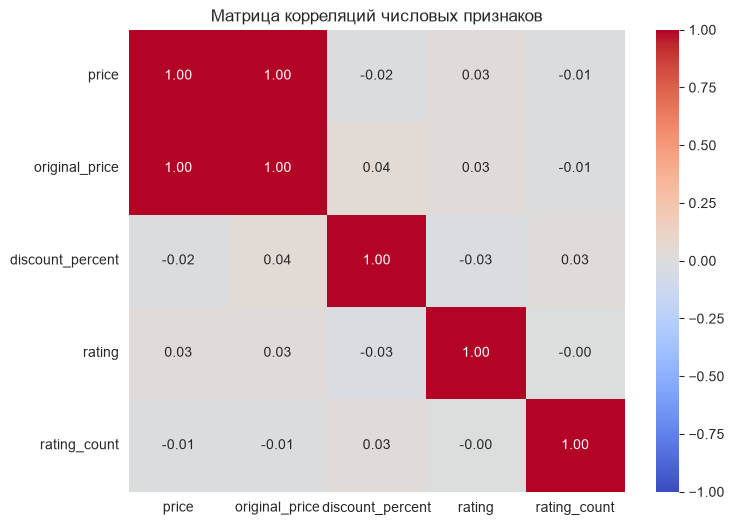

In [16]:
corr = df[['price', 'original_price', 'discount_percent', 'rating', 'rating_count']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Матрица корреляций числовых признаков')
plt.show()

**Комментарий к матрице корреляций:**  
Единственная сильная корреляция — между `price` и `original_price` (≈ 0.98), 
что логично, так как скидка рассчитывается от исходной цены.  
Остальные пары признаков коррелируют слабо (|r| < 0.2):  
- `discount_percent` и `price` практически не связаны — скидки назначаются 
  независимо от ценового уровня;  
- `rating` и `rating_count` также независимы.  

Вывод: для прогнозных задач потребуются нелинейные модели или новые 
признаки (например, отношение цены к средней по категории).